In [3]:
import ipywidgets as widgets
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import base64
from io import BytesIO
from PIL import Image
import json

In [4]:
path = "viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage1/Coyo"
fs = pa.hdfs.connect(user='mpi')
files = fs.ls(path)
files = [x for x in files if x.endswith("parquet")]

/tmp/ipykernel_43170/3702799992.py:2: FutureWarning: pyarrow.hdfs.connect is deprecated as of 2.0.0, please use pyarrow.fs.HadoopFileSystem instead.
  fs = pa.hdfs.connect(user='mpi')


In [5]:
x = np.random.choice(files)
print(x)
df = pq.read_table(x).to_pandas()

viewfs://hadoop-lt-cluster/home/reco_wl/mpi/luoxinchen/recovlm_dataset_stage1/Coyo/rank-1-2011f772-d278-11ef-91d4-946daee90e30.parquet


25/01/15 06:19:20 WARN hdfs.DFSClient Thread-15: hedgedFetchBlockByteRange waited 50ms to read from DatanodeInfoWithStorage[10.84.91.15:50010,DS-1abfd2f1-c894-4cf4-8dab-6a13dac97c98,DISK] LocatedBlock{BP-1375695010-10.80.51.153-1669032439483:blk_81607877338_80617198290; getBlockSize()=261426281; corrupt=false; offset=268435456; activeIndex=2; locs=[DatanodeInfoWithStorage[10.84.91.15:50010,DS-1abfd2f1-c894-4cf4-8dab-6a13dac97c98,DISK], DatanodeInfoWithStorage[10.84.248.237:50010,DS-ff7991ec-ba9a-4a8c-a9a3-b2fa524faf66,DISK]]} 261360745 65536; spawning hedged read
25/01/15 06:19:20 WARN hdfs.DFSClient Thread-15: hedgedFetchBlockByteRange waited 50ms to read from DatanodeInfoWithStorage[10.84.91.15:50010,DS-1abfd2f1-c894-4cf4-8dab-6a13dac97c98,DISK] LocatedBlock{BP-1375695010-10.80.51.153-1669032439483:blk_81607877338_80617198290; getBlockSize()=261426281; corrupt=false; offset=268435456; activeIndex=2; locs=[DatanodeInfoWithStorage[10.84.91.15:50010,DS-1abfd2f1-c894-4cf4-8dab-6a13dac97c

images 1
source Coyo messages [{'role': 'user', 'content': [{'type': 'image', 'image': 'jpg'}, {'type': 'text', 'text': 'Please observe this image carefully and generate a brief description for it.'}]}, {'role': 'assistant', 'content': [{'type': 'text', 'text': 'KYLIE MINOGUE - Kiss Me Once: Live At The Sse Hydro - 2CD/DVD.'}]}] segments None


'jpg'

(384, 384)

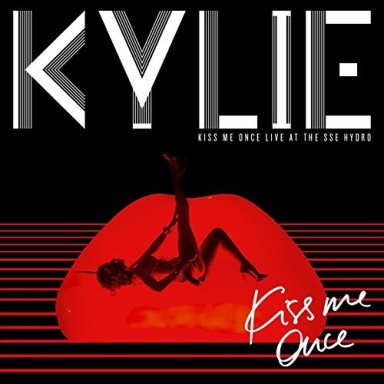

In [10]:
def decode_base64_image(base64_string):
    # 解码base64字符串并返回PIL图像对象
    image_data = base64.b64decode(base64_string)
    image = Image.open(BytesIO(image_data))
    return image
    
def display_sample(sample):
    images = json.loads(sample.pop('images'))
    print('images', len(images))
    messages = json.loads(sample['messages'])
    segments = json.loads(sample['segments'])
    print('source', sample['source'], 'messages', messages, 'segments', segments)
    for name, base64_string in images.items():
        image = decode_base64_image(base64_string)
        display(name, image.size, image)

display_sample(df.sample().iloc[0].to_dict())